In [20]:
#To load automatically updates from libraries without re-running import cells
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Loading sources file

In [21]:
from astropy.io import fits
from astropy.table import Table
from pre_processing_utils import (
    remove_corrupted_rows,
)

catalog_4FGL = fits.open("4FGL-DR2.fit")
fits_data = catalog_4FGL[1].data

catalog = Table(fits_data)

catalog = remove_corrupted_rows(catalog)  # Remove catalog rows with missing data

### Preparing Pulsars and AGNs train and test data

In [30]:
from pre_processing_utils import (
    get_associated_sources_dataframe,
    scale_df_data,
    get_network_data_from_df_data,
)

df = get_associated_sources_dataframe(catalog)

scaled_data, scaler = scale_df_data(df)
# scaled_df = add_category_id(scaled_df)

random_state = 52
X_train, X_val, X_test, y_train, y_val, y_test, class_weights_dict = (
    get_network_data_from_df_data(scaled_data, random_state)
)

Number on Nan values= 0


### Parameters scan

In [ ]:
from sequential_network import *

layers = [1, 2, 3]
neurons = [32, 64, 128]
batch_sizes = [16, 32, 64, 128]
# batch_sizes = [16]

netw_opt_params = Sequential_Network.scan_network_parameters(
    X_train,
    y_train,
    X_val,
    y_val,
    len(X_train[0]),
    layers,
    neurons,
    batch_sizes,
    3,
    class_weight=class_weights_dict,
)

print(netw_opt_params)

### Re-train on optimal parameter

In [24]:
from sequential_network import *

seq_netw = Sequential_Network(
    len(X_train[0]), 1, 64, 3, class_weight=class_weights_dict
)
seq_netw.build_model()
seq_netw.compile_model()
train_history = seq_netw.train(
    x_train=X_train,
    y_train=y_train,
    x_val=X_val,
    y_val=y_val,
    batch_size=16,
    epochs=200,
)

model_loss = sum(train_history.history["val_loss"][-3:]) / 3

Model built correctly...

Model summary: 



Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,155 (4.51 KB)

 Trainable params: 1,155 (4.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 128: early stopping


### Result visualization

In [25]:
from constants import SOURCES_CATEGORIES

# score=model.evaluate(X_test,Y_test,verbose=verbose)
conf_matrix = seq_netw.calc_test_confusion_matrix(X_test, y_test, SOURCES_CATEGORIES)
print(conf_matrix)

seq_netw.get_performance_metrics(X_test, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
        PULSAR  AGN  OTHERS
PULSAR      36    1       4
AGN          9  482      34
OTHERS       4   13      35
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.88      0.80        41
           1       0.97      0.92      0.94       525
           2       0.48      0.67      0.56        52

    accuracy                           0.89       618
   macro avg       0.73      0.82      0.77       618
weighted avg       0.91      0.89      0.90       618

Overall Accuracy: 0.8948


#### Plotting probability distributions of Pulsars and AGNs according to the network

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step


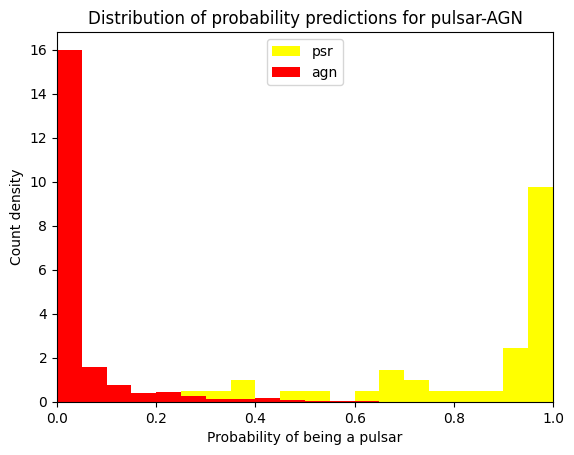

In [ ]:
from plot_utils import create_puls_agn_probs_histogram

all_sources_predictions = seq_netw.calc_prediction_probabilities(X_test, y_test)

pulsar_probs = [prediction[1] for prediction in all_sources_predictions if prediction[0] == 0]
agn_probs = [prediction[1] for prediction in all_sources_predictions if prediction[0] == 1]

create_puls_agn_probs_histogram(pulsar_probs, agn_probs)

### Using the network to classify unassociated sources

In [39]:
from pre_processing_utils import (
    get_unassociated_sources_dataframe,
    scale_df_data,
)

unass_df = get_unassociated_sources_dataframe(catalog)

scaled_unass_data, scaler = scale_df_data(unass_df, scaler)

unass_X_test = scaled_unass_data.select_dtypes(include=[np.number]).values

Number on Nan values= 0


#### Plotting probability distributions of Unassociated sources according to the network

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step


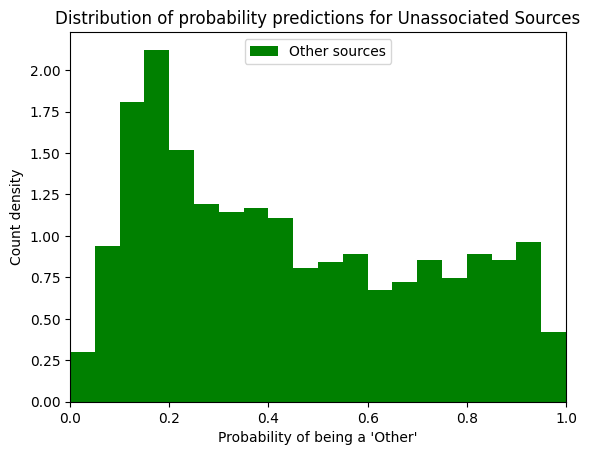

In [41]:
from plot_utils import create_unassociates_sources_histogram

unass_predictions = seq_netw.calc_prediction_probabilities(unass_X_test)

create_unassociates_sources_histogram(unass_predictions)